In [1]:
run_names = ["p-est-250827-144050", "p-est-250824-141443", "p-est-250823-182728", "p-est-250822-161807", "p-est-250822-160040", "p-est-250822-144330"]
option_name = "_scaled"

(0.0, 5.0)

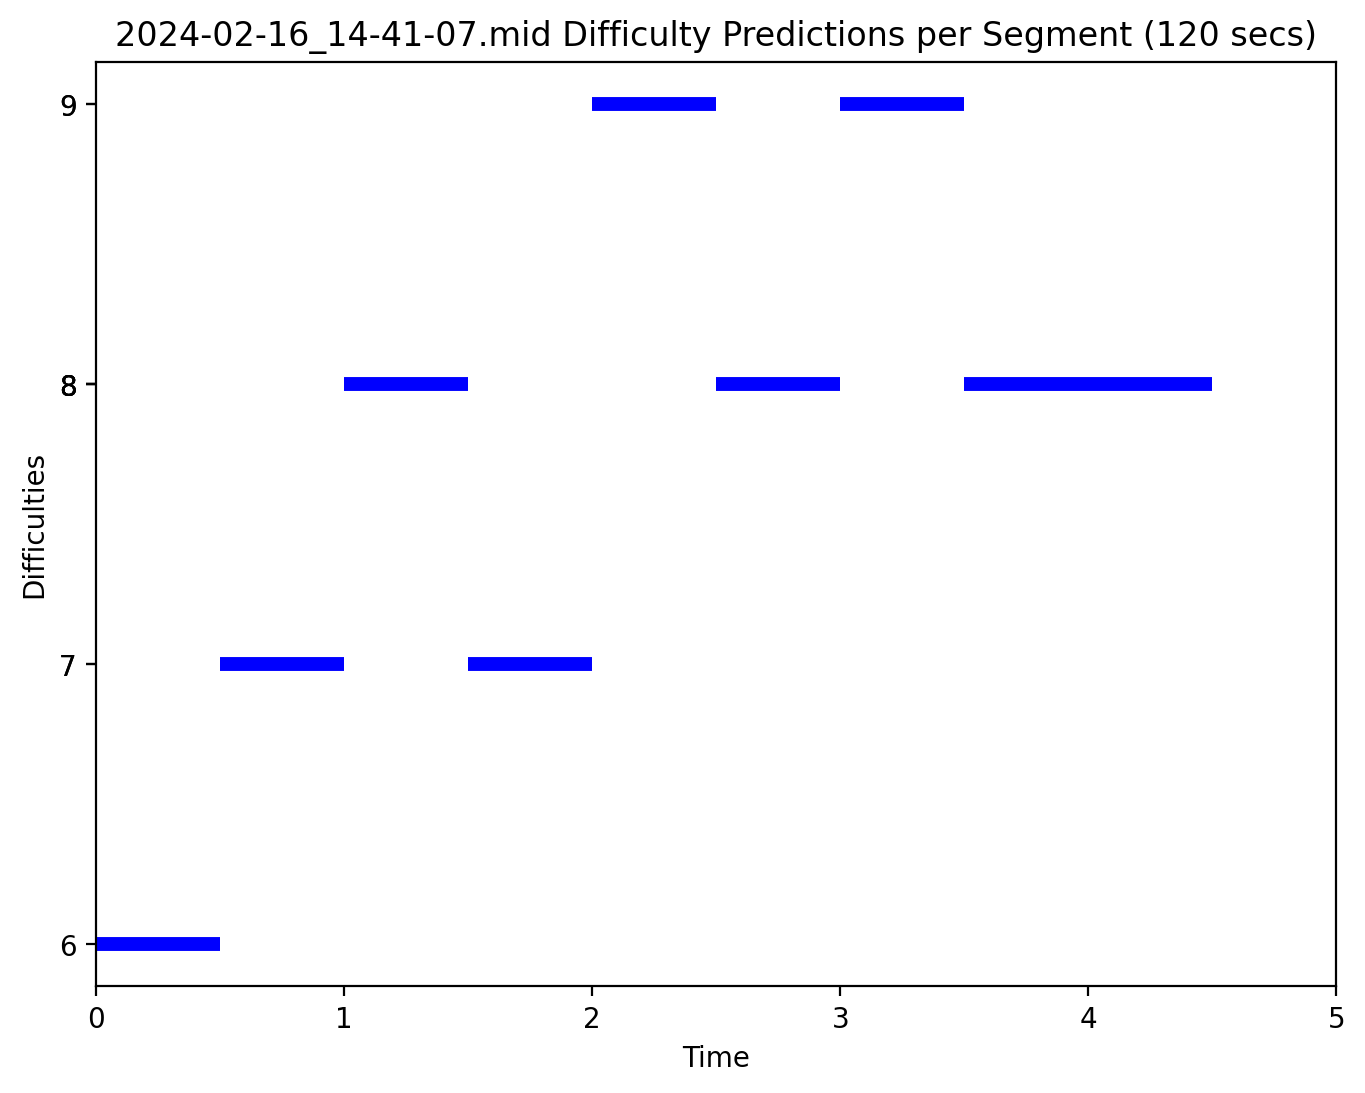

In [6]:
import torch, json, os
from model import RubricNet, MidiFeatures
import numpy as np
import matplotlib.pyplot as plt

model_snapshot_path = f'/Users/simhyeongju/AVAPT/EDA/runs/p-est-250822-160040/model_snapshots/model_bestvalidation.pt'
rubricnet = RubricNet()
rubricnet.load_state_dict(torch.load(model_snapshot_path, weights_only=False))


mid_folder_path = "/Users/simhyeongju/AVAPT/data/pianovam/midi"
# filename = "2024-02-15_23-14-13.mid"
filename = "2024-02-16_14-41-07.mid"

midi_path = os.path.join(mid_folder_path, filename)
midi_features = MidiFeatures(midi_path).extract_features_segments(segment_length_sec=120)
criteria = MidiFeatures(midi_path).get_numeric_features_names()
# Extract features
features = torch.tensor(midi_features)
# Get predictions
with torch.no_grad():
    predictions = rubricnet.predict(features).numpy().tolist()
    scores = rubricnet.get_descriptive_scores(features.float())

first_score = scores[0].reshape(-1).numpy().tolist() * 100

# 점수를 기준으로 데이터 정렬 (낮은 점수 -> 높은 점수)
sorted_data = sorted(zip(first_score, criteria))
sorted_scores, sorted_criteria = zip(*sorted_data)

# 점수에 따라 색상을 다르게 설정 (Viridis 컬러맵 사용)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(sorted_scores)))

# 그래프 생성
fig, ax = plt.subplots(figsize=(12, 8))

# 가로 막대 그래프 그리기
bars = ax.barh(sorted_criteria, sorted_scores, color=colors)

# 제목 및 레이블 설정
ax.set_title('RubricNet Score Distribution', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Criteria', fontsize=12)

# 그래프 디자인 개선
# 불필요한 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# 눈금 표시 제거
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

# 가독성을 위한 배경 격자 추가
ax.grid(axis='x', linestyle='--', alpha=0.6)

# x축 범위 설정 (여유 공간 추가)
ax.set_xlim(0, max(sorted_scores) + 1)

# 각 막대 끝에 점수 값 표시
for bar in bars:
    width = round(bar.get_width(), 3)
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
            f'{width}',
            va='center', ha='left', fontsize=10)

# 레이아웃을 깔끔하게 조정
plt.tight_layout()

# 이미지 파일로 저장
plt.savefig("rubricnet_scores_1.png", dpi=300)

plt.close()

# 그래프 그리기

fig, ax = plt.subplots(figsize=(8, 6))

# 각 인덱스에 대해 수평선 그리기
for i, pred in enumerate(predictions):
    ax.hlines(y=pred, xmin=i*0.5, xmax=i*0.5+0.5, color='blue', linestyle='-', linewidth=5)

# y축 눈금 설정
ax.set_yticks(predictions)

# 레이블과 제목 설정
ax.set_xlabel("Time")
ax.set_ylabel("Difficulties")
ax.set_title("2024-02-16_14-41-07.mid Difficulty Predictions per Segment (120 secs)")

# 범례 표시 (선이 많을 경우 중복될 수 있어 하나만 표시되도록 처리)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys()) # 범례가 필요하다면 이 줄의 주석을 해제하세요.

# x축 범위 설정 (선이 더 잘보이도록)
ax.set_xlim(0, 5)

/Users/simhyeongju/AVAPT/.venv/lib/python3.10/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/simhyeongju/AVAPT/EDA/model/model.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


[25, 44, 27, 52, 65, 52, 20, 4, 0]


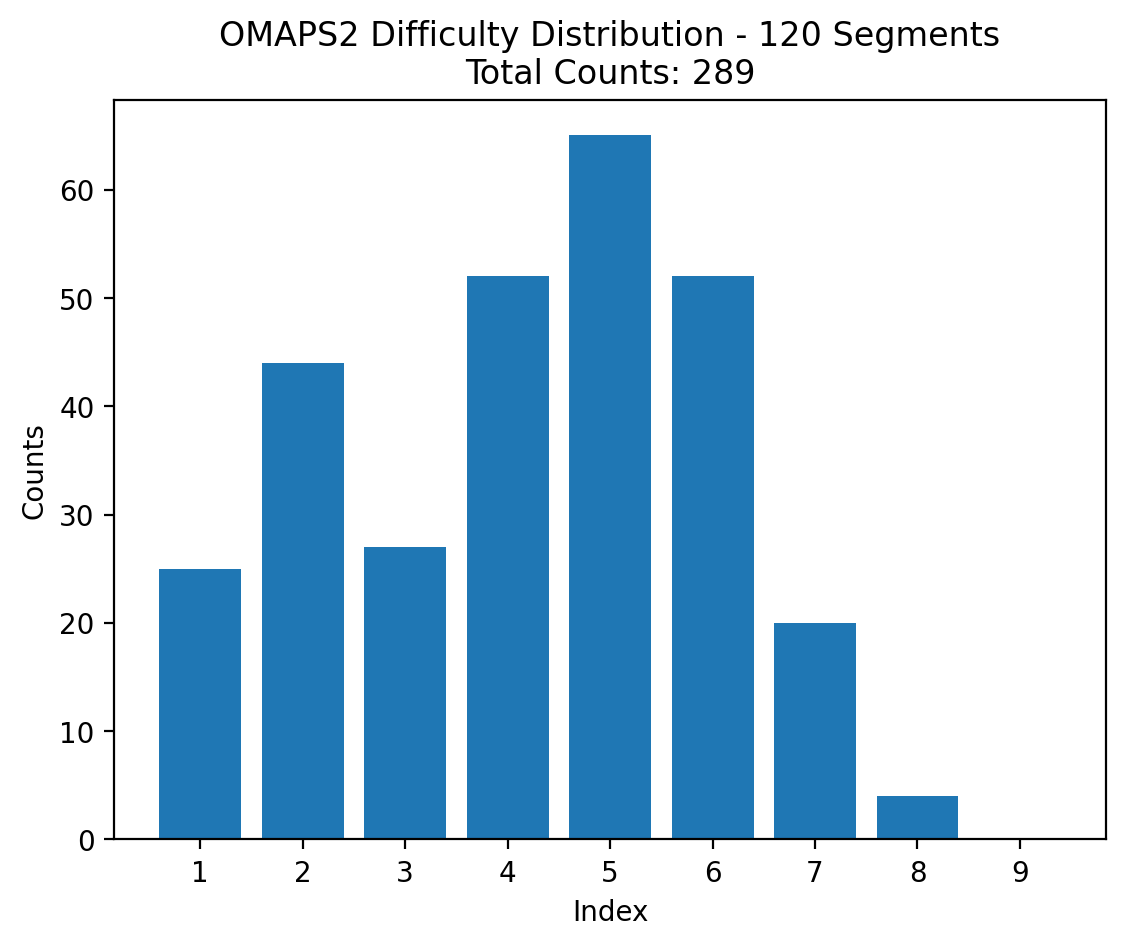

In [1]:
from RubricStatistics import get_mid_files_statistics_per_segments
import matplotlib.pyplot as plt

omaps_stats = get_mid_files_statistics_per_segments(runs_name = "p-est-250822-160040", mid_folder_path = "/Users/simhyeongju/AVAPT/data/omaps/OMAPS2/midi")

import numpy as np
indices = np.arange(1, 10)

print(omaps_stats)
# 막대 그래프 생성
plt.bar(indices, omaps_stats)

# 그래프 제목 및 축 레이블 추가
plt.title('OMAPS2 Difficulty Distribution - 120 Segments\nTotal Counts: {}'.format(sum(omaps_stats)))
plt.xlabel('Index')
plt.ylabel('Counts')

# x축 눈금을 1부터 9까지 정수로 설정
plt.xticks(indices)

# 그래프를 이미지 파일로 저장
plt.savefig(f'data_distribution_plots/omaps_p-est-250822-160040_120segs.png')
# plt.clf()

In [2]:
from RubricStatistics import get_mid_files_statistics
import matplotlib.pyplot as plt

for run_name in run_names:
    pianovam_stats = get_mid_files_statistics(runs_name = run_name, mid_folder_path = "/Users/simhyeongju/AVAPT/data/pianovam/midi")

    import numpy as np
    indices = np.arange(1, 10)

    print(pianovam_stats)
    # 막대 그래프 생성
    plt.bar(indices, pianovam_stats)

    # 그래프 제목 및 축 레이블 추가
    plt.title('PianoVam Difficulty Distribution\nTotal Counts: {}'.format(sum(pianovam_stats)))
    plt.xlabel('Index')
    plt.ylabel('Counts')

    # x축 눈금을 1부터 9까지 정수로 설정
    plt.xticks(indices)

    # 그래프를 이미지 파일로 저장
    plt.savefig(f'data_distribution_plots/pianovam{option_name}_{run_name}.png')
    plt.clf()

/Users/simhyeongju/AVAPT/.venv/lib/python3.10/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/simhyeongju/AVAPT/EDA/model/model.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


[8, 6, 9, 13, 22, 33, 16, 0, 0]
[8, 6, 9, 13, 22, 33, 16, 0, 0]
[7, 6, 5, 13, 17, 41, 18, 0, 0]
[7, 7, 7, 14, 26, 36, 10, 0, 0]
[8, 10, 11, 11, 21, 34, 12, 0, 0]
[8, 6, 9, 13, 22, 33, 16, 0, 0]


<Figure size 640x480 with 0 Axes>

In [3]:
from RubricStatistics import get_mid_files_statistics
import matplotlib.pyplot as plt

for run_name in run_names:
    omaps_stats = get_mid_files_statistics(runs_name=run_name, mid_folder_path="/Users/simhyeongju/AVAPT/data/omaps/OMAPS2/midi")

    import numpy as np
    indices = np.arange(1, 10)

    # 막대 그래프 생성
    plt.bar(indices, omaps_stats)
    print(omaps_stats)

    # 그래프 제목 및 축 레이블 추가
    plt.title('OMAPS Difficulty Distribution\nTotal Counts: {}'.format(sum(omaps_stats)))
    plt.xlabel('Index')
    plt.ylabel('Counts')

    # x축 눈금을 1부터 9까지 정수로 설정
    plt.xticks(indices)

    # 그래프를 이미지 파일로 저장
    plt.savefig(f'data_distribution_plots/omaps{option_name}_{run_name}.png')
    plt.clf()

[13, 13, 5, 37, 62, 51, 23, 2, 0]
[13, 13, 5, 37, 62, 51, 23, 2, 0]
[8, 13, 6, 33, 64, 52, 24, 6, 0]
[12, 14, 14, 43, 56, 48, 17, 2, 0]
[12, 15, 16, 40, 57, 40, 21, 5, 0]
[13, 13, 5, 37, 62, 51, 23, 2, 0]


<Figure size 640x480 with 0 Axes>